In [14]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
from rasterio.warp import calculate_default_transform, reproject, Resampling


In [15]:
gebco_path = "F:\data_water\GEBCO_13_Jun_2026_ad6c9e1be196\gebco_2026_n36.218_s35.07_w22.974_e24.115_geotiff.tif"
target_tif = r"F:\data_water\processed\bands\Bands 20240117.tif"
out_path = r"F:\data_water\gebco_reprojected.tif"


*** EMODner reference file info ***
crs EPSG:4326
shape (275, 274)
Bounds BoundingBox(left=22.97499999999999, bottom=35.070833333333326, right=24.116666666666674, top=36.21666666666666)
Resolution (0.004166666666666729, 0.004166666666666663)
No. of bands 1
Driver: GTiff
mo data value -32767.0
min: -3991.0
max: 2372.0
mean: -1028.2191
Water pixels only:
Min depth: 1.0 m
Max depth: 3991.0 m
Mean depth: 1287.9735 m


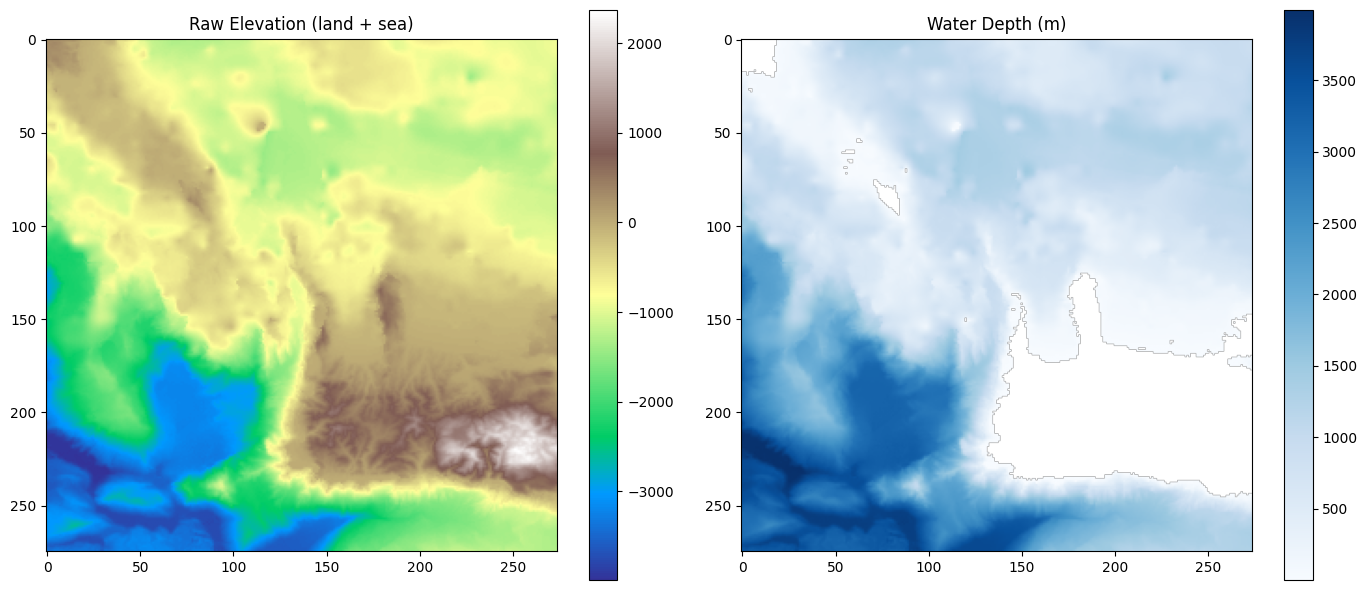

In [ ]:


with rasterio.open(gebco_path) as src:
    print("*** EMODner reference file info ***")
    print("crs",src.crs)
    print("shape",src.shape)
    print("Bounds",src.bounds)
    print("Resolution", src.res)
    print("No. of bands", src.count)
    print("Driver:", src.driver)
    nodata = src.nodata
    print("mo data value", src.nodata)
    depth = src.read(1).astype('float32')

print("min:", np.nanmin(depth))
print("max:", np.nanmax(depth))
print("mean:", np.nanmean(depth))

# Replace nodata with NaN
depth = np.where(depth == nodata, np.nan, depth)

# Keep only water pixels (negative elevation = below sea level)
depth_water = np.where(depth < 0, depth, np.nan)

# Convert to positive depth (easier to work with)
depth_positive = np.abs(depth_water)

print("Water pixels only:")
print("Min depth:", np.nanmin(depth_positive), "m")
print("Max depth:", np.nanmax(depth_positive), "m")
print("Mean depth:", np.nanmean(depth_positive), "m")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(depth, cmap='terrain')
axes[0].set_title('Raw Elevation (land + sea)')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(depth_positive, cmap='Blues')
axes[1].set_title('Water Depth (m)')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()



shallow pixels =  1598
total water pixels = 64841


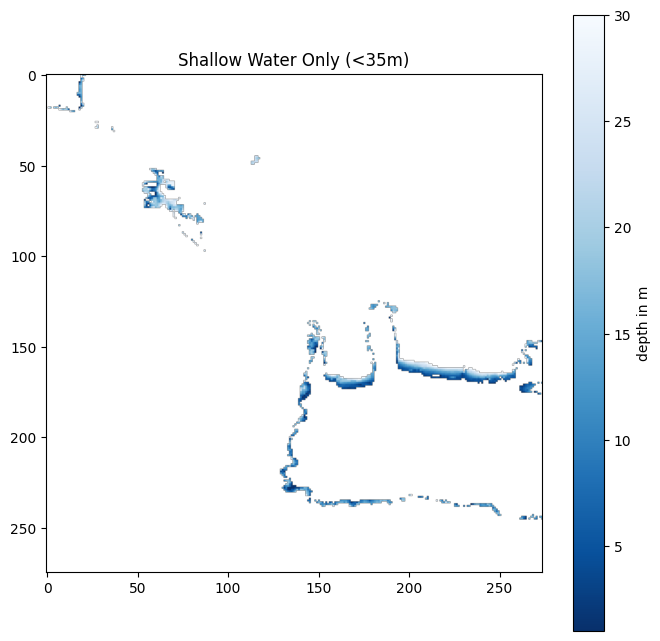

In [9]:
shallow_mask = (depth_positive >=0) & (depth_positive<=30)
depth_shallow = np.where(shallow_mask, depth_positive, np.nan)

print("shallow pixels = ", np.sum(shallow_mask))
print("total water pixels =", np.sum(~np.isnan(depth_positive)))

plt.figure(figsize=(8,8))
plt.imshow(depth_shallow, cmap = "Blues_r")
plt.colorbar(label = 'depth in m')
plt.title('Shallow Water Only (<35m)')
plt.show()

In [17]:
with rasterio.open(target_tif) as src:
    target_crs = src.crs
    target_transform = src.transform
    target_width = src.width
    target_height = src.height
    target_profile = src.profile.copy()

print("target _crs", target_crs)
print("target shape:", target_height, target_width)

with rasterio.open(gebco_path) as src:

    profile = target_profile.copy()
    profile.update({
        "count": 1,
        "dtype": "float32",
        "crs": target_crs,
        "transform": target_transform,
        "width": target_width,
        "height": target_height,
        "nodata": -32767.0

    })

    with rasterio.open(out_path, 'w', **profile) as dst:

        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),

            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,

            dst_transform=target_transform,
            dst_crs=target_crs,
            dst_nodata=-32767.0,

            resampling=Resampling.bilinear
        )
print("gebco reference reprojected and matched to Sentinel grid!")

target _crs EPSG:32634
target shape: 10980 10980
gebco reference reprojected and matched to Sentinel grid!


In [18]:

with rasterio.open(out_path) as src:
    print("New CRS:", src.crs)
    print("New shape:", src.shape)
    print("New resolution:", src.res)
    print("New transform:", src.transform)

    data = src.read(1).astype("float32")
    data = np.where(data == -32767.0, np.nan, data)

    print("Min depth:", np.nanmin(data))
    print("Max depth:", np.nanmax(data))
    print("Mean depth:", np.nanmean(data))

New CRS: EPSG:32634
New shape: (10980, 10980)
New resolution: (10.0, 10.0)
New transform: | 10.00, 0.00, 699960.00|
| 0.00,-10.00, 4000020.00|
| 0.00, 0.00, 1.00|
Min depth: -3795.3562
Max depth: 2371.6858
Mean depth: -771.5926
